# SCARA Diffusion Policy: trajectory predictions

Deze notebook voert de policy **offline** uit op een opgenomen validation-episode. Er wordt niets naar TCS of de robot gestuurd.

Kopieer voor gebruik alleen `policy_best.ckpt`, `train_config.json` en `dataset_stats.pkl` vanaf Vast naar de lokale checkpointmap. `policy_best.ckpt` wordt tijdens training atomisch vervangen, dus een gelijktijdige download levert geen half checkpoint op.

## 1. Een snapshot vanaf Vast ophalen

Voer dit uit in een **lokale terminal op je laptop**, niet in een notebookcel. Met je huidige Vast-instance:

```bash
mkdir -p /home/tomoya/scara_ws/src/scara_diffusion_policy/checkpoints/vast_best_snapshot

scp -P 44853 \
  root@38.117.87.52:/workspace/scara_diffusion_kaggle/checkpoints/leaf_cutting_diffusion_h32_a16/policy_best.ckpt \
  root@38.117.87.52:/workspace/scara_diffusion_kaggle/checkpoints/leaf_cutting_diffusion_h32_a16/train_config.json \
  root@38.117.87.52:/workspace/scara_diffusion_kaggle/checkpoints/leaf_cutting_diffusion_h32_a16/dataset_stats.pkl \
  /home/tomoya/scara_ws/src/scara_diffusion_policy/checkpoints/vast_best_snapshot/
```

Op basis van het huidige logbestand is dit `policy_best.ckpt` van epoch 4. De lokale kopie blijft die snapshot, ook wanneer Vast daarna verder traint.

In [76]:
from pathlib import Path
import sys

import h5py
import matplotlib.pyplot as plt
import numpy as np
import torch

SRC_ROOT = Path("/home/tomoya/scara_ws/src")
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

from scara_diffusion_policy.constants import JOINT_NAMES
from scara_diffusion_policy.eval import dataset_input, load_policy, predict

CKPT_DIR = SRC_ROOT / "scara_diffusion_policy/checkpoints/vast_best_snapshot"
DATASET_DIR = SRC_ROOT / "scara_act/datasets/leaf_cutting_experiment_rgb_640x480"
CHECKPOINT = "policy_epoch_21.ckpt"
VAL_EPISODE_INDEX = 1
FRAME = 0
N_SAMPLES = 10
SEED = 42
HZ = 30.0
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for path in [CKPT_DIR / CHECKPOINT, CKPT_DIR / "train_config.json", CKPT_DIR / "dataset_stats.pkl"]:
    if not path.exists():
        raise FileNotFoundError(f"Ontbreekt: {path}\nVoer eerst het scp-commando hierboven uit.")

print("Device:", DEVICE)

Device: cuda


In [77]:
policy, config = load_policy(CKPT_DIR, CHECKPOINT, DEVICE)
val_episode_ids = config["val_episode_ids"]
episode = int(val_episode_ids[VAL_EPISODE_INDEX])
n_actions = int(config["model"]["n_action_steps"])

print(f"Checkpoint: {CKPT_DIR / CHECKPOINT}")
print(f"Validation episode: {episode} ({VAL_EPISODE_INDEX + 1}/{len(val_episode_ids)})")
print(f"Model: horizon={config['model']['horizon']}, observations={config['model']['n_obs_steps']}, returned actions={n_actions}")

Checkpoint: /home/tomoya/scara_ws/src/scara_diffusion_policy/checkpoints/vast_best_snapshot/policy_epoch_21.ckpt
Validation episode: 243 (2/31)
Model: horizon=32, observations=2, returned actions=16


## 2. Eén voorspelde chunk

De zwarte stippellijn is de opgenomen demonstratie. De blauwe lijnen zijn afzonderlijke diffusion-samples met verschillende seeds; de dikke blauwe lijn is hun gemiddelde.

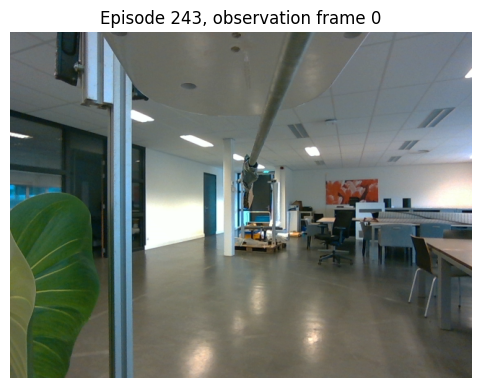

In [78]:
history, recorded = dataset_input(config, str(DATASET_DIR), episode, FRAME)
camera_name = config["camera_names"][0]

plt.figure(figsize=(8, 4.5))
plt.imshow(history[-1][1][camera_name])
plt.title(f"Episode {episode}, observation frame {FRAME}")
plt.axis("off")
plt.show()

In [79]:
predictions, latencies = [], []
for sample_index in range(N_SAMPLES):
    prediction, latency = predict(policy, history, config, DEVICE, SEED + sample_index)
    predictions.append(prediction)
    latencies.append(latency)

predictions = np.stack(predictions)
mean_prediction = predictions.mean(axis=0)
mae_per_joint = np.abs(mean_prediction - recorded).mean(axis=0)

print(f"Gemiddelde inference: {np.mean(latencies) * 1000:.1f} ms")
for name, error in zip(JOINT_NAMES, mae_per_joint):
    unit = "m" if name == "J1" else "rad"
    print(f"{name} MAE: {error:.6f} {unit}")

Gemiddelde inference: 407.7 ms
J1 MAE: 0.005852 m
J2 MAE: 0.015554 rad
J3 MAE: 0.053131 rad
J4 MAE: 0.161889 rad


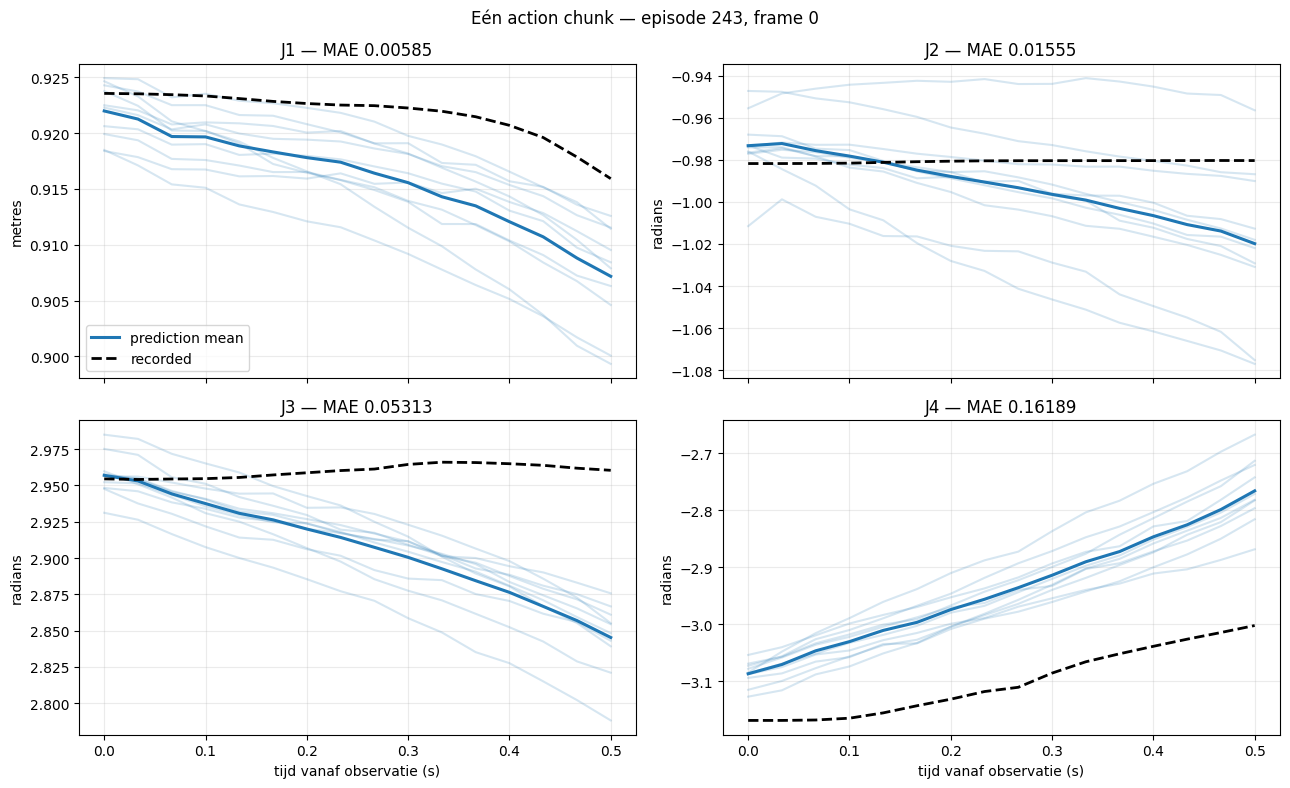

In [80]:
time_axis = np.arange(n_actions) / HZ
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True)

for joint_index, (axis, name) in enumerate(zip(axes.flat, JOINT_NAMES)):
    for sample in predictions:
        axis.plot(time_axis, sample[:, joint_index], color="tab:blue", alpha=0.18)
    axis.plot(time_axis, mean_prediction[:, joint_index], color="tab:blue", linewidth=2.2, label="prediction mean")
    axis.plot(time_axis, recorded[:, joint_index], "k--", linewidth=2.0, label="recorded")
    axis.set_title(f"{name} — MAE {mae_per_joint[joint_index]:.5f}")
    axis.set_ylabel("metres" if name == "J1" else "radians")
    axis.grid(alpha=0.25)

for axis in axes[-1]:
    axis.set_xlabel("tijd vanaf observatie (s)")
axes.flat[0].legend()
fig.suptitle(f"Eén action chunk — episode {episode}, frame {FRAME}")
fig.tight_layout()
plt.show()

## 3. Meerdere chunks achter elkaar

Hieronder worden meerdere voorspelde chunks aan elkaar geplakt. Iedere chunk gebruikt opnieuw de **opgenomen** camera-observatie en qpos van die frame. Dit meet offline imitatiekwaliteit; het is geen gesloten robot-rollout waarin eerdere voorspelfouten de volgende observatie beïnvloeden.

In [74]:
START_FRAME = FRAME
N_CHUNKS = 10

episode_path = DATASET_DIR / f"episode_{episode}.hdf5"
with h5py.File(episode_path, "r") as root:
    episode_length = int(root["action"].shape[0])

last_start = episode_length - n_actions
frames = list(range(START_FRAME, last_start + 1, n_actions))[:N_CHUNKS]
if not frames:
    raise ValueError(f"START_FRAME {START_FRAME} is too late for episode length {episode_length}")

predicted_chunks, recorded_chunks = [], []
for chunk_index, frame in enumerate(frames):
    chunk_history, chunk_recorded = dataset_input(config, str(DATASET_DIR), episode, frame)
    chunk_prediction, _ = predict(policy, chunk_history, config, DEVICE, SEED + 100 + chunk_index)
    predicted_chunks.append(chunk_prediction)
    recorded_chunks.append(chunk_recorded)

predicted_trajectory = np.concatenate(predicted_chunks)
recorded_trajectory = np.concatenate(recorded_chunks)
trajectory_mae = np.abs(predicted_trajectory - recorded_trajectory).mean(axis=0)

print(f"Geplot: {len(frames)} chunks, {len(predicted_trajectory)} acties, {len(predicted_trajectory) / HZ:.2f} s")
for name, error in zip(JOINT_NAMES, trajectory_mae):
    unit = "m" if name == "J1" else "rad"
    print(f"{name} MAE: {error:.6f} {unit}")

Geplot: 10 chunks, 160 acties, 5.33 s
J1 MAE: 0.004300 m
J2 MAE: 0.046894 rad
J3 MAE: 0.036852 rad
J4 MAE: 0.054333 rad


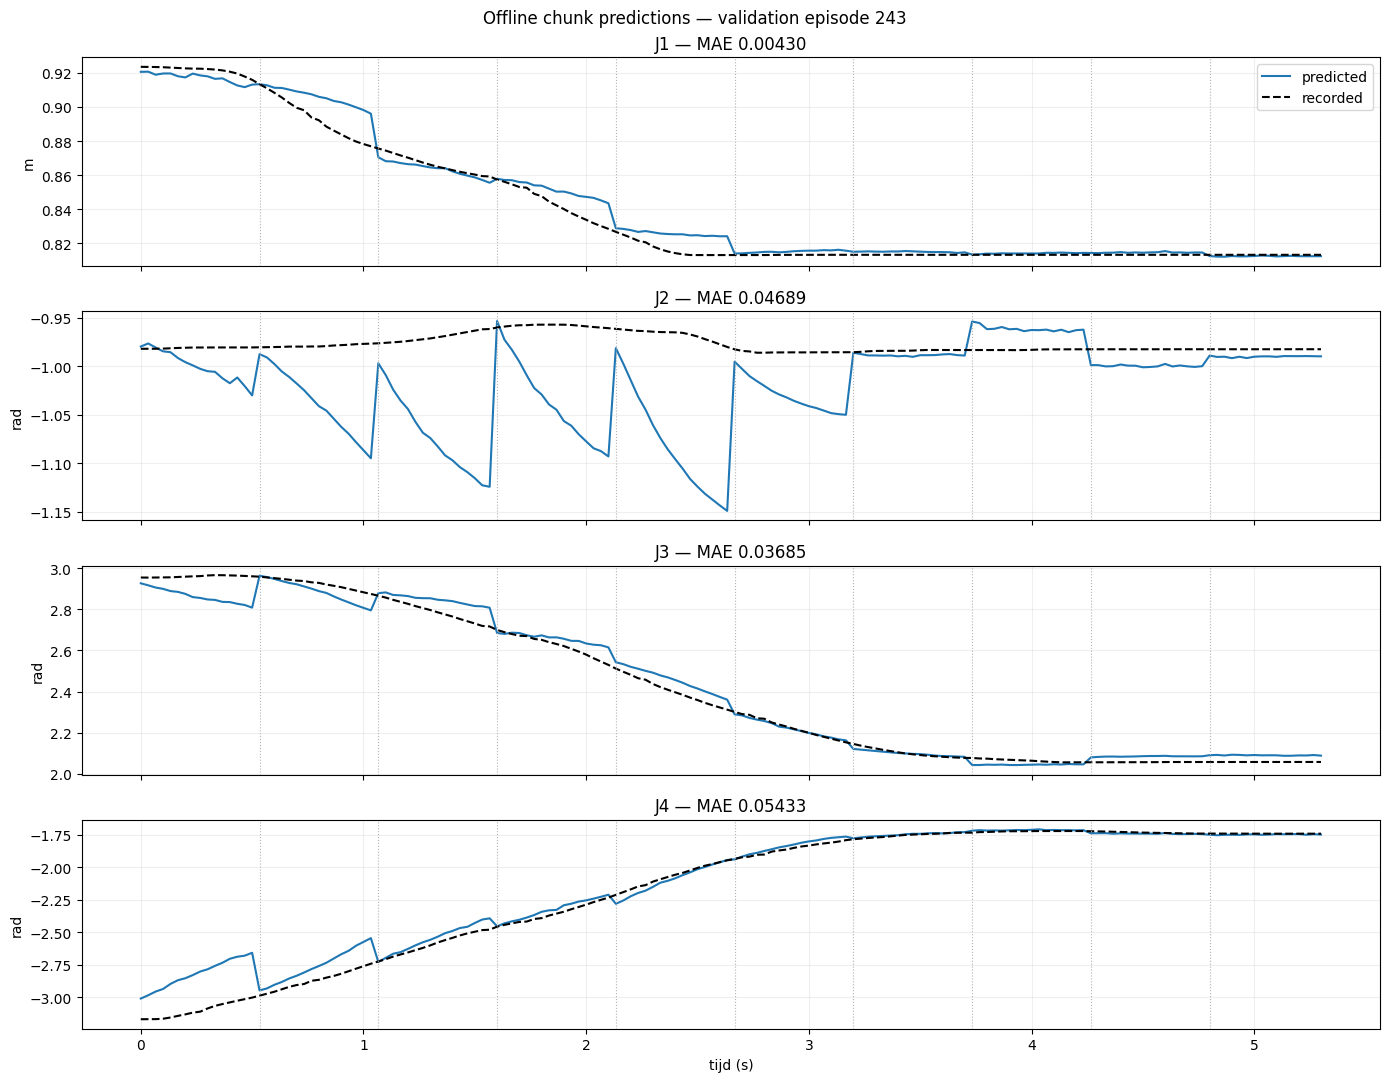

In [75]:
trajectory_time = np.arange(len(predicted_trajectory)) / HZ
fig, axes = plt.subplots(4, 1, figsize=(14, 11), sharex=True)

for joint_index, (axis, name) in enumerate(zip(axes, JOINT_NAMES)):
    axis.plot(trajectory_time, predicted_trajectory[:, joint_index], color="tab:blue", label="predicted")
    axis.plot(trajectory_time, recorded_trajectory[:, joint_index], "k--", label="recorded")
    for boundary in range(n_actions, len(predicted_trajectory), n_actions):
        axis.axvline(boundary / HZ, color="0.7", linestyle=":", linewidth=0.8)
    axis.set_ylabel("m" if name == "J1" else "rad")
    axis.set_title(f"{name} — MAE {trajectory_mae[joint_index]:.5f}")
    axis.grid(alpha=0.2)

axes[0].legend()
axes[-1].set_xlabel("tijd (s)")
fig.suptitle(f"Offline chunk predictions — validation episode {episode}")
fig.tight_layout()
plt.show()

## 4. Checkpoints eerlijk vergelijken: epoch 4, 11 en 14

Deze vergelijking gebruikt voor ieder checkpoint exact dezelfde tien validation-episodes, drie frames per episode en drie diffusion-seeds. Daarmee is het resultaat veel minder afhankelijk van één toevallig gunstige trajectory.

Epoch 10 is niet meer terug te halen: de oorspronkelijke run gebruikte `save_every=50`, waardoor `policy_last.ckpt` na iedere epoch werd overschreven. `policy_last_current.ckpt` is de bewaarde epoch-11-snapshot die het dichtst bij epoch 10 ligt.

In [64]:
import gc
import pickle

COMPARE_CHECKPOINTS = {
    "epoch 4": "policy_best.ckpt",
    "epoch 11": "policy_last_current.ckpt",
    "epoch 14": "policy_epoch_14.ckpt",
}
COMPARE_EPISODES = 10
COMPARE_FRAMES = (30, 90, 150)
COMPARE_SEEDS = (42, 43, 44)

for checkpoint_name in COMPARE_CHECKPOINTS.values():
    if not (CKPT_DIR / checkpoint_name).exists():
        raise FileNotFoundError(CKPT_DIR / checkpoint_name)

with (CKPT_DIR / "dataset_stats.pkl").open("rb") as source:
    comparison_stats = pickle.load(source)
action_range = np.asarray(comparison_stats["action_max"]) - np.asarray(comparison_stats["action_min"])

comparison_results = {}
for label, checkpoint_name in COMPARE_CHECKPOINTS.items():
    comparison_policy, comparison_config = load_policy(CKPT_DIR, checkpoint_name, DEVICE)
    errors, predicted_deltas, recorded_deltas = [], [], []
    for episode_index, episode_id in enumerate(comparison_config["val_episode_ids"][:COMPARE_EPISODES]):
        for frame in COMPARE_FRAMES:
            chunk_history, chunk_recorded = dataset_input(
                comparison_config, str(DATASET_DIR), int(episode_id), frame
            )
            for seed in COMPARE_SEEDS:
                chunk_prediction, _ = predict(
                    comparison_policy,
                    chunk_history,
                    comparison_config,
                    DEVICE,
                    seed + episode_index * 1000 + frame,
                )
                errors.append(np.abs(chunk_prediction - chunk_recorded))
                predicted_deltas.append(np.abs(np.diff(chunk_prediction, axis=0)).mean(axis=0))
                recorded_deltas.append(np.abs(np.diff(chunk_recorded, axis=0)).mean(axis=0))

    errors = np.stack(errors)
    comparison_results[label] = {
        "first4": errors[:, :4].mean(axis=(0, 1)),
        "first8": errors[:, :8].mean(axis=(0, 1)),
        "full16": errors.mean(axis=(0, 1)),
        "per_step_range_pct": (errors / action_range).mean(axis=(0, 2)) * 100,
        "per_joint_range_pct": errors.mean(axis=(0, 1)) / action_range * 100,
        "overall_range_pct": float((errors.mean(axis=(0, 1)) / action_range).mean() * 100),
        "roughness_ratio": np.mean(predicted_deltas, axis=0) / np.mean(recorded_deltas, axis=0),
    }
    del comparison_policy
    gc.collect()
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()

print("Volledige 16-action trajectory-MAE per joint:")
print(f"{'checkpoint':<10} {'J1 (m)':>10} {'J2 (rad)':>11} {'J3 (rad)':>11} {'J4 (rad)':>11} {'gem. % range':>14}")
for label, result in comparison_results.items():
    values = result["full16"]
    print(f"{label:<10} {values[0]:>10.6f} {values[1]:>11.6f} {values[2]:>11.6f} {values[3]:>11.6f} {result['overall_range_pct']:>13.3f}%")

for reference in ("epoch 4", "epoch 11"):
    reference_score = comparison_results[reference]["overall_range_pct"]
    epoch14_score = comparison_results["epoch 14"]["overall_range_pct"]
    improvement = (reference_score - epoch14_score) / reference_score * 100
    print(f"Epoch 14 verbetering versus {reference}: {improvement:.2f}%")

Volledige 16-action trajectory-MAE per joint:
checkpoint     J1 (m)    J2 (rad)    J3 (rad)    J4 (rad)   gem. % range
epoch 4      0.015385    0.081505    0.081868    0.113420         1.672%
epoch 11     0.011610    0.058746    0.061843    0.076342         1.219%
epoch 14     0.011068    0.051655    0.057052    0.067690         1.108%
Epoch 14 verbetering versus epoch 4: 33.74%
Epoch 14 verbetering versus epoch 11: 9.07%


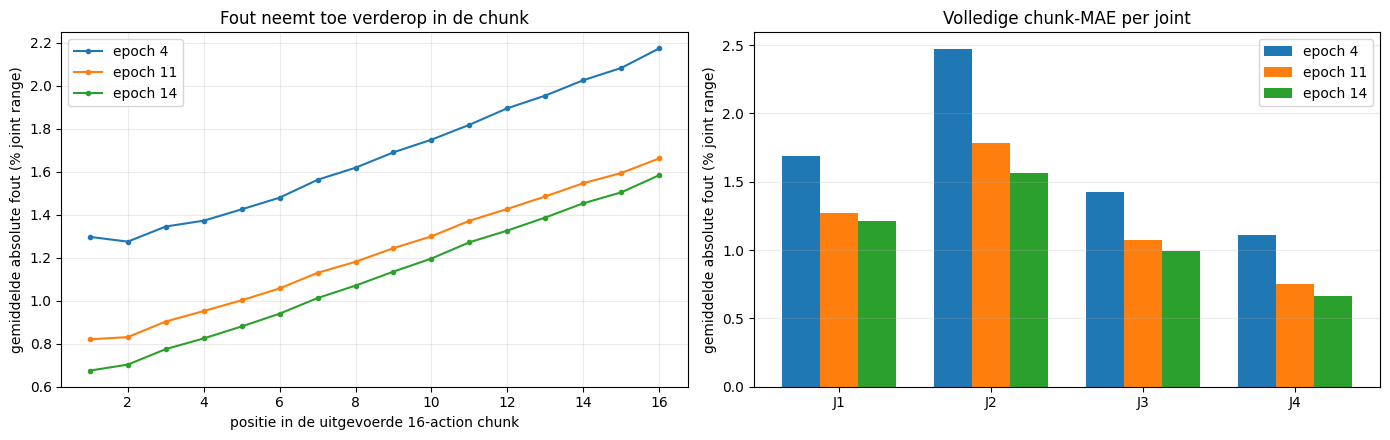

In [65]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

for label, result in comparison_results.items():
    axes[0].plot(
        np.arange(1, len(result["per_step_range_pct"]) + 1),
        result["per_step_range_pct"],
        marker="o",
        markersize=3,
        label=label,
    )
axes[0].set_title("Fout neemt toe verderop in de chunk")
axes[0].set_xlabel("positie in de uitgevoerde 16-action chunk")
axes[0].set_ylabel("gemiddelde absolute fout (% joint range)")
axes[0].grid(alpha=0.25)
axes[0].legend()

x = np.arange(len(JOINT_NAMES))
width = 0.25
for index, (label, result) in enumerate(comparison_results.items()):
    axes[1].bar(x + (index - 1) * width, result["per_joint_range_pct"], width, label=label)
axes[1].set_title("Volledige chunk-MAE per joint")
axes[1].set_xticks(x, JOINT_NAMES)
axes[1].set_ylabel("gemiddelde absolute fout (% joint range)")
axes[1].grid(axis="y", alpha=0.25)
axes[1].legend()

fig.tight_layout()
plt.show()

## 5. Iedere observatie opnieuw plannen: alleen de eerste actie uitvoeren

Het model en zijn getrainde `n_action_steps=16` blijven ongewijzigd. Per validation-frame wordt nog steeds een volledige chunk voorspeld, maar alleen `prediction[0]` wordt gebruikt. Daarna krijgt de policy meteen de volgende opgenomen camera- en jointobservatie. De oranje baseline voert telkens alle 16 voorspelde acties uit; beide lijnen gebruiken hetzelfde checkpoint, dezelfde frames en reproduceerbare diffusion-seeds.

Dit is een **teacher-forced offline evaluatie**: iedere nieuwe observatie komt uit de demonstratie, niet uit een toestand die de voorspelde robotactie werkelijk heeft veroorzaakt. Het meet daardoor correct de one-step prediction, maar is optimistischer dan een echte robotrollout.

Referentieresultaat voor epoch 14, validation-episode 243, frames 0–159: de gemiddelde genormaliseerde MAE daalde van **0,783%** bij 16 uitgevoerde acties per planning naar **0,437%** bij één actie per planning, een verbetering van **44,2%**.

In [67]:
import pickle

REPLAN_CHECKPOINT = "policy_epoch_14.ckpt"
REPLAN_START_FRAME = FRAME
REPLAN_STEPS = 160
REPLAN_SEED = 10_000

replan_policy, replan_config = load_policy(CKPT_DIR, REPLAN_CHECKPOINT, DEVICE)
replan_episode = int(replan_config["val_episode_ids"][VAL_EPISODE_INDEX])
available_actions = int(replan_config["model"]["n_action_steps"])
with h5py.File(DATASET_DIR / f"episode_{replan_episode}.hdf5", "r") as root:
    episode_length = int(root["action"].shape[0])

# De laatste recorderactie is kunstmatig gelijk aan de laatste qpos en wordt overgeslagen.
end_frame = min(REPLAN_START_FRAME + REPLAN_STEPS, episode_length - 1)
replan_frames = list(range(REPLAN_START_FRAME, end_frame))

one_step_prediction, one_step_recorded, replan_latencies = [], [], []
for offset, frame in enumerate(replan_frames):
    step_history, step_recorded = dataset_input(replan_config, str(DATASET_DIR), replan_episode, frame)
    step_prediction, latency = predict(replan_policy, step_history, replan_config, DEVICE, REPLAN_SEED + offset)
    one_step_prediction.append(step_prediction[0])
    one_step_recorded.append(step_recorded[0])
    replan_latencies.append(latency)

chunk_prediction = []
for frame in range(REPLAN_START_FRAME, end_frame, available_actions):
    chunk_history, _ = dataset_input(replan_config, str(DATASET_DIR), replan_episode, frame)
    predicted_chunk, _ = predict(
        replan_policy, chunk_history, replan_config, DEVICE, REPLAN_SEED + frame - REPLAN_START_FRAME
    )
    chunk_prediction.extend(predicted_chunk[: min(available_actions, end_frame - frame)])

one_step_prediction = np.asarray(one_step_prediction)
one_step_recorded = np.asarray(one_step_recorded)
chunk_prediction = np.asarray(chunk_prediction)
one_step_mae = np.abs(one_step_prediction - one_step_recorded).mean(axis=0)
chunk_mae = np.abs(chunk_prediction - one_step_recorded).mean(axis=0)

with (CKPT_DIR / "dataset_stats.pkl").open("rb") as source:
    replan_stats = pickle.load(source)
replan_action_range = np.asarray(replan_stats["action_max"]) - np.asarray(replan_stats["action_min"])
one_step_score = float((one_step_mae / replan_action_range).mean() * 100)
chunk_score = float((chunk_mae / replan_action_range).mean() * 100)

print(f"Checkpoint: {REPLAN_CHECKPOINT}; validation episode {replan_episode}; {len(replan_frames)} acties ({len(replan_frames) / HZ:.2f} s)")
print(f"Gemiddelde inference: {np.mean(replan_latencies) * 1000:.1f} ms; 30 Hz-budget: {1000 / HZ:.1f} ms")
print(f"Alleen eerste actie: {one_step_score:.3f}% van jointbereik")
print(f"Volledige chunks:    {chunk_score:.3f}% van jointbereik")
print(f"Verbetering door iedere stap opnieuw te plannen: {(chunk_score - one_step_score) / chunk_score * 100:.1f}%")
for name, first_error, chunk_error in zip(JOINT_NAMES, one_step_mae, chunk_mae):
    unit = "m" if name == "J1" else "rad"
    print(f"{name}: first-only {first_error:.6f} {unit}, chunk-16 {chunk_error:.6f} {unit}")

Checkpoint: policy_epoch_14.ckpt; validation episode 243; 160 acties (5.33 s)
Gemiddelde inference: 436.4 ms; 30 Hz-budget: 33.3 ms
Alleen eerste actie: 0.457% van jointbereik
Volledige chunks:    0.883% van jointbereik
Verbetering door iedere stap opnieuw te plannen: 48.2%
J1: first-only 0.002679 m, chunk-16 0.005046 m
J2: first-only 0.025825 rad, chunk-16 0.054360 rad
J3: first-only 0.026438 rad, chunk-16 0.035789 rad
J4: first-only 0.030034 rad, chunk-16 0.072501 rad


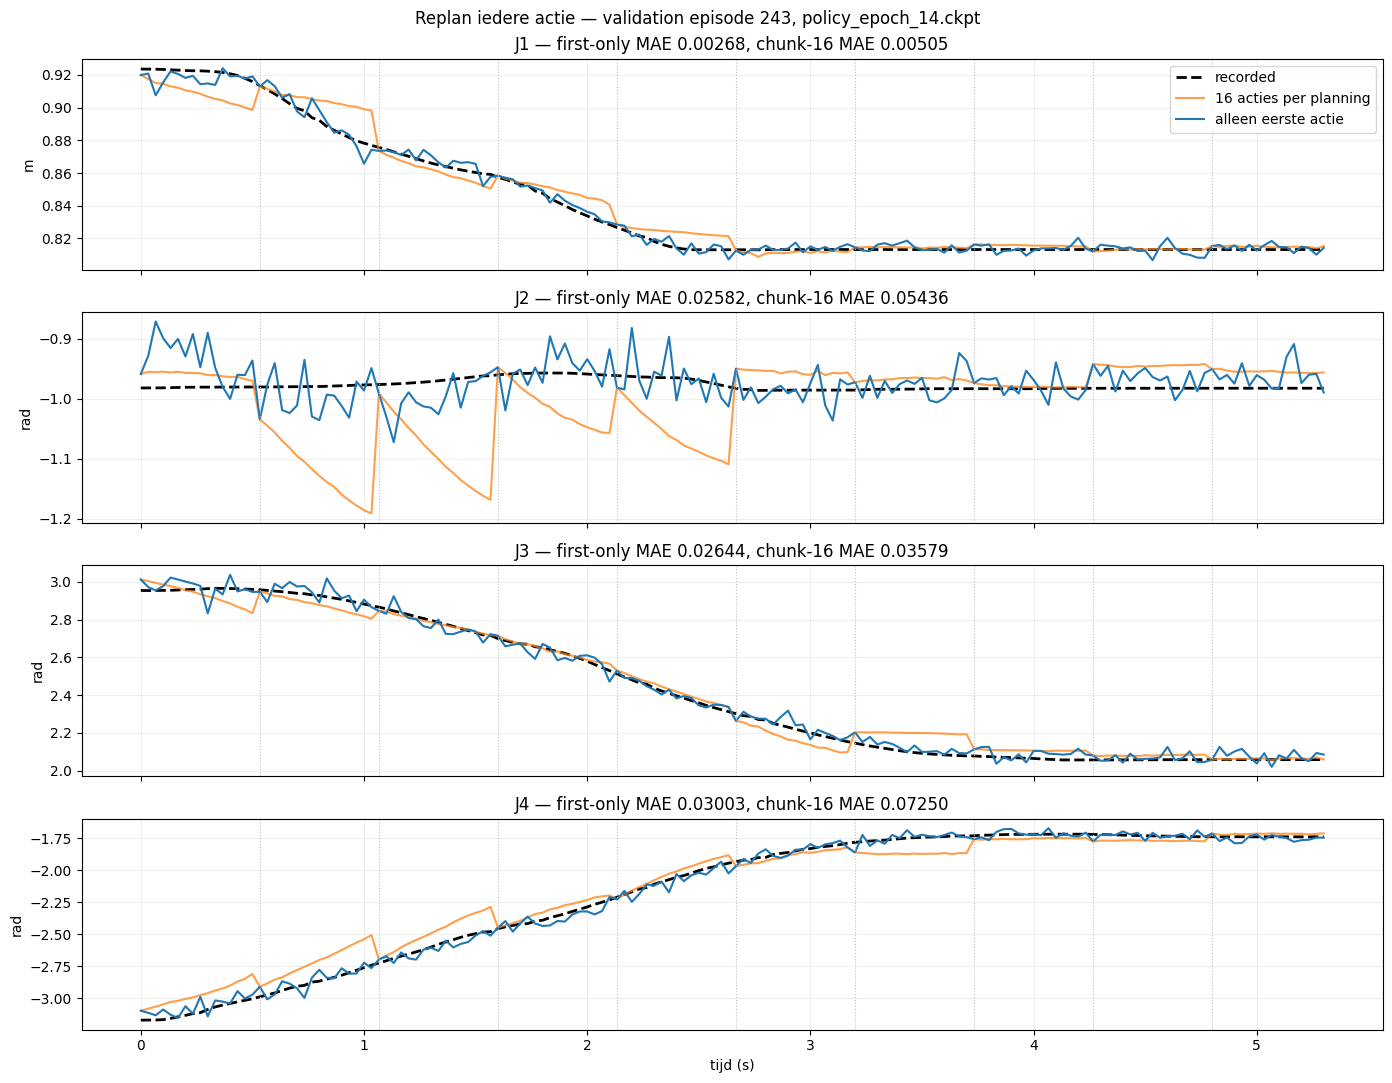

In [68]:
replan_time = (np.asarray(replan_frames) - REPLAN_START_FRAME) / HZ
fig, axes = plt.subplots(4, 1, figsize=(14, 11), sharex=True)

for joint_index, (axis, name) in enumerate(zip(axes, JOINT_NAMES)):
    axis.plot(replan_time, one_step_recorded[:, joint_index], "k--", linewidth=2, label="recorded")
    axis.plot(replan_time, chunk_prediction[:, joint_index], color="tab:orange", alpha=0.75, label="16 acties per planning")
    axis.plot(replan_time, one_step_prediction[:, joint_index], color="tab:blue", label="alleen eerste actie")
    for boundary in range(available_actions, len(replan_frames), available_actions):
        axis.axvline(boundary / HZ, color="0.75", linestyle=":", linewidth=0.8)
    unit = "m" if name == "J1" else "rad"
    axis.set_ylabel(unit)
    axis.set_title(f"{name} — first-only MAE {one_step_mae[joint_index]:.5f}, chunk-16 MAE {chunk_mae[joint_index]:.5f}")
    axis.grid(alpha=0.2)

axes[0].legend()
axes[-1].set_xlabel("tijd (s)")
fig.suptitle(f"Replan iedere actie — validation episode {replan_episode}, {REPLAN_CHECKPOINT}")
fig.tight_layout()
plt.show()

### Interpretatie

- Vergelijk vooral de vorm, richting en timing van de curves; alleen een lage gemiddelde fout is niet voldoende.
- Grote spreiding tussen de blauwe diffusion-samples betekent dat de policy onzeker of multimodaal is.
- De verticale stippellijnen in de lange plot zijn grenzen waar een nieuwe camera-observatie wordt gebruikt.
- De action-steps-1-plot replannet correct ieder frame; alleen de eerste policyactie wordt gebruikt.
- Goede offline voorspellingen garanderen nog geen veilige closed-loop robotuitrol. Test echte uitvoering later met lage snelheid en de bestaande limietcontroles.